<a href="https://colab.research.google.com/github/wavymejti/KursAI1/blob/main/klasyfikacja_binarna_cz_2_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

# 1) Prawdziwe wyniki: 1 = sukces, 0 = porażka
y_prawda = [
    1,1,1,1,1,1,1,1,1,1,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0
]

# 2) Przewidywania 4 modeli

# Model 1
y_model1 = [
    1,1,1,1,1,1,1,0,0,0,
    1,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0
]

# Model 2
y_model2 = [
    1,1,1,1,
    0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0,0
]

# Model 3
y_model3 = [
    1,1,1,1,1,1,1,1,1,1,
    1,1,1,1,1,1,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
]

# Model 4
y_model4 = [
    1,1,1,1,1,1,1,1,1,
    0,
    1,1,1,1,
    0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
]



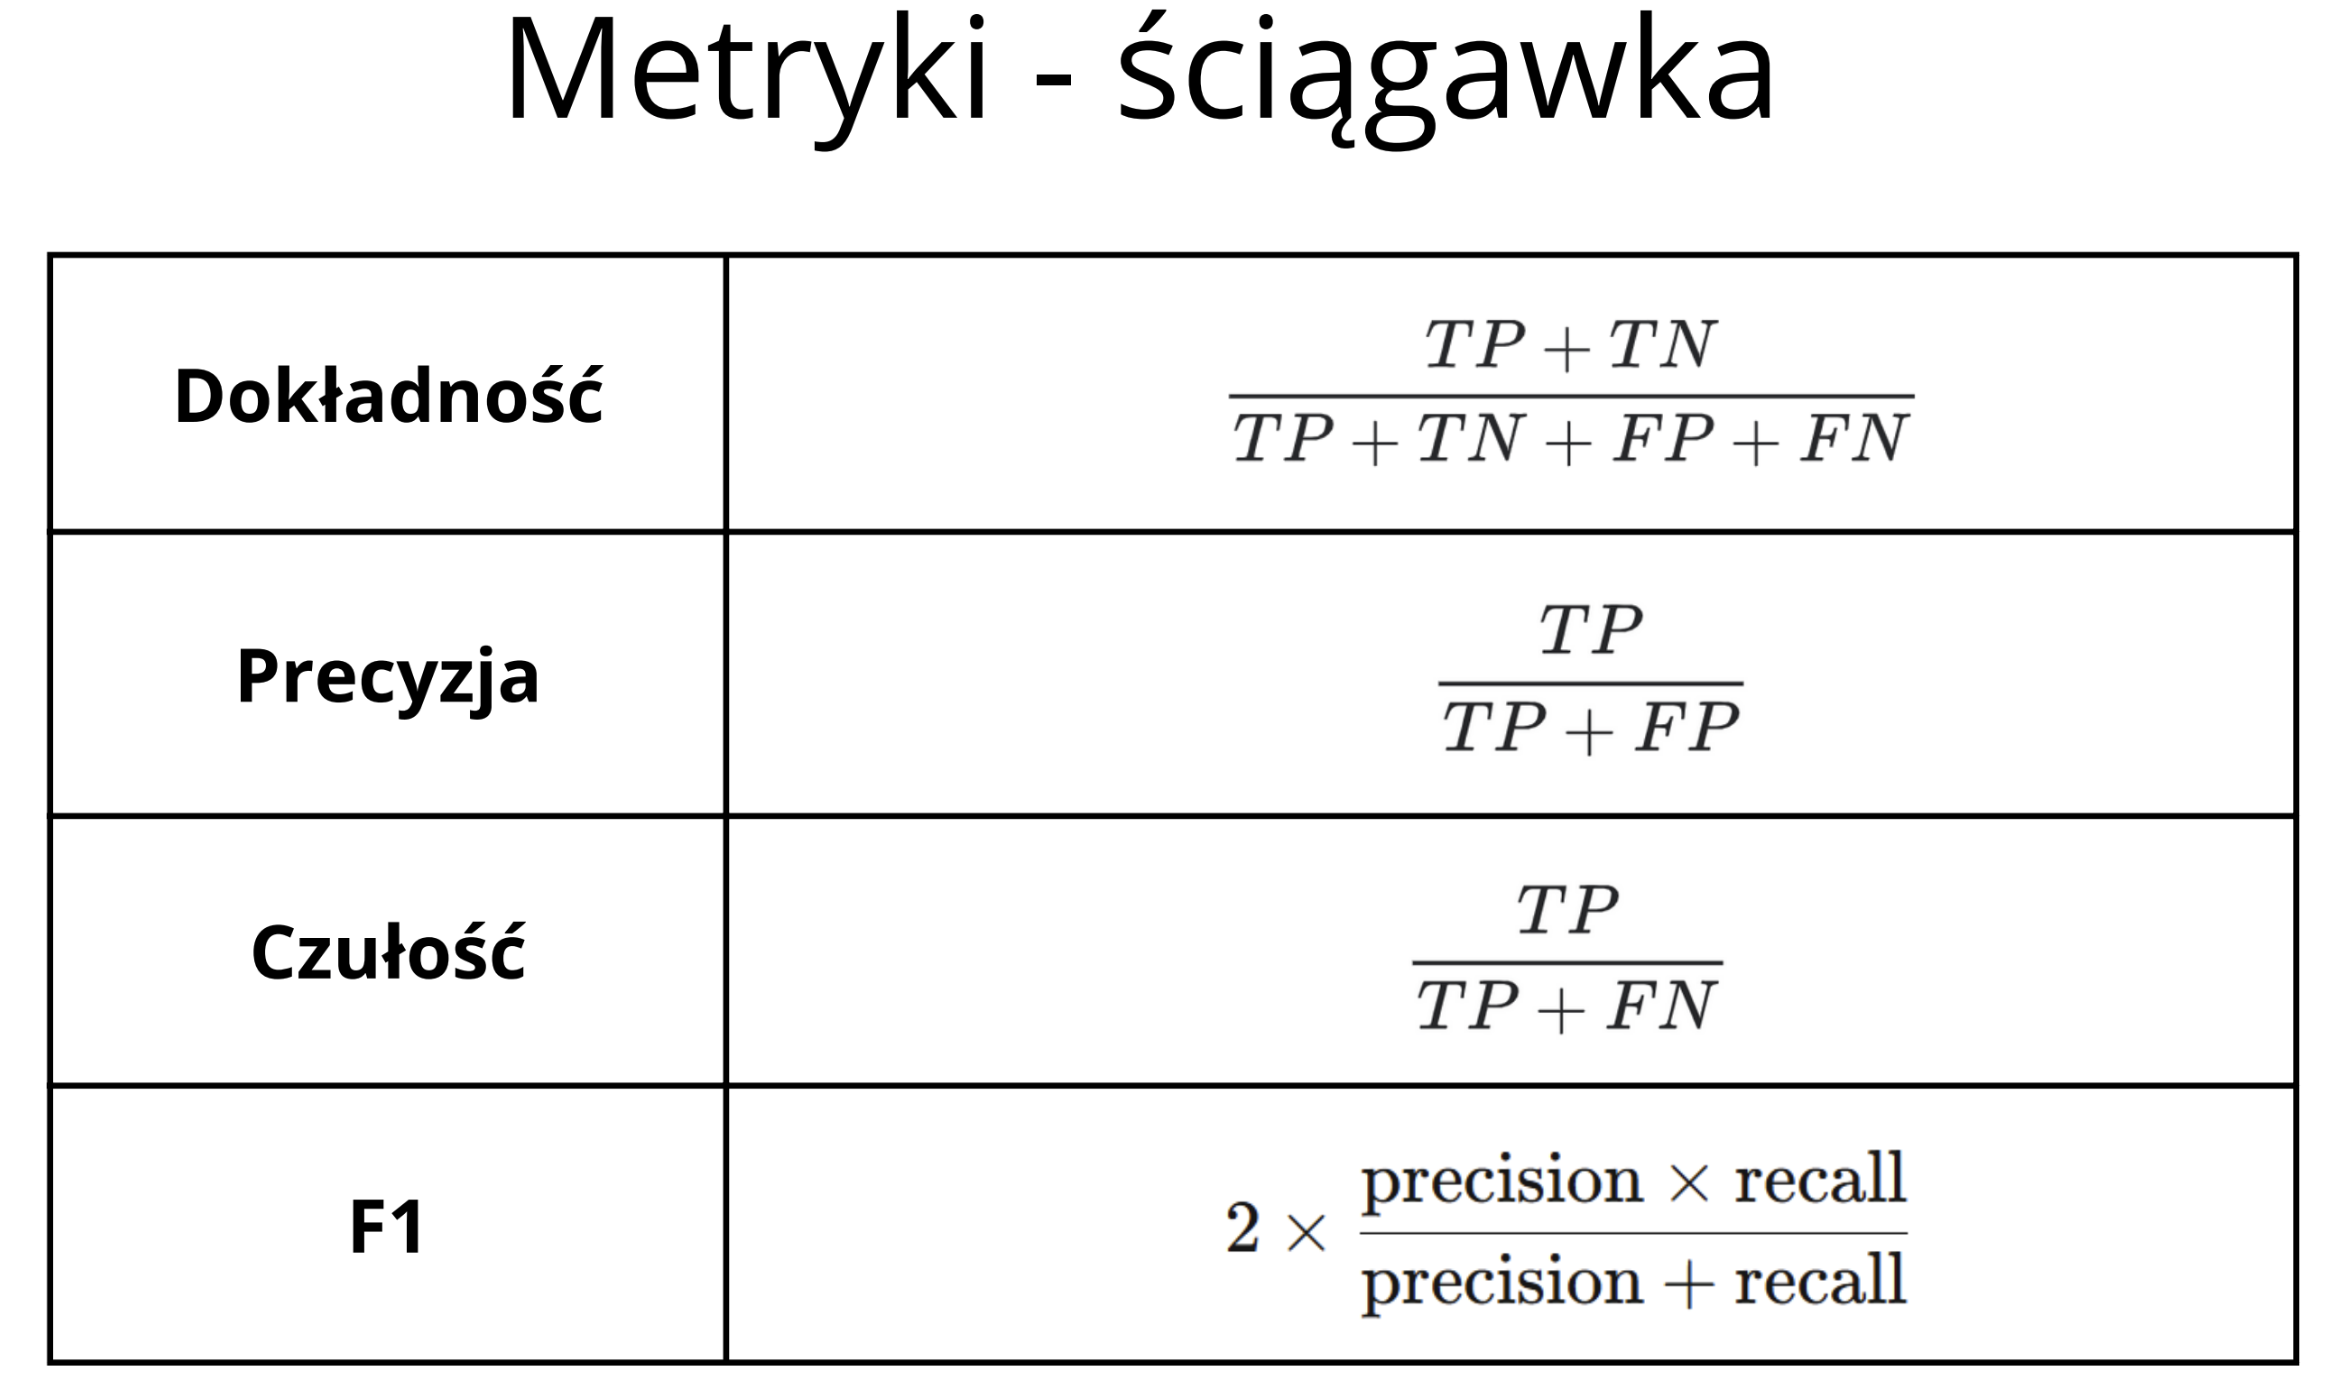

TP (True Positive, prawdziwie pozytywne)
Model przewidział sukces (1) i rzeczywiście był sukces.
→ „Model powiedział TAK i miał rację”.

FP (False Positive, fałszywie pozytywne)
Model przewidział sukces (1), ale w rzeczywistości była porażka (0).
→ „Model powiedział TAK, ale się pomylił” (fałszywy alarm).

TN (True Negative, prawdziwie negatywne)
Model przewidział porażkę (0) i rzeczywiście była porażka.
→ „Model powiedział NIE i miał rację”.

FN (False Negative, fałszywie negatywne)
Model przewidział porażkę (0), ale w rzeczywistości był sukces (1).
→ „Model powiedział NIE, ale się pomylił” (przegapił sukces).

In [14]:
def policz_doklodnosc(prawda, model):
  poprawne = 0
  for i in range(len(prawda)):
    if prawda[i] == model[i]:
      poprawne += 1
  return poprawne / len(prawda)

def policz_precyzje(prawda, model):
  tp = fp = 0
  for i in range(len(prawda)):
    if model[i] == 1:
      if prawda[i] == 1: tp += 1
      else: fp += 1
  if (tp + fp) == 0: return 0
  return tp / (tp + fp)

def policz_czulosc(prawda, model):
  tp = 0
  fn = 0
  for i in range (len(prawda)):
    if prawda[i] == 1:
      if model[i] == 1: tp += 1
      else: fn += 1
  if (tp + fn) == 0: return 0.0
  return tp/(tp + fn)

def policz_f1(prawda, model):
  return (2*policz_precyzje(prawda, model)*policz_czulosc(prawda,model)/(policz_precyzje(prawda, model)+policz_czulosc(prawda,model)))

In [15]:
# raport dzialania z wyswietalnei wynikow
model = {
    "model 1" : y_model1,
    "model 2" : y_model2,
    "model 3" : y_model3,
    "model 4" : y_model4
}

for nazwa, przewidywania in model.items():
  dokladnosc = policz_doklodnosc(y_prawda, przewidywania)
  precyzja = policz_precyzje(y_prawda, przewidywania)
  czulosc = policz_czulosc(y_prawda, przewidywania)
  f1 = policz_f1(y_prawda, przewidywania)
  print("="*30)
  print(nazwa)
  print(f"Dokładność: {dokladnosc}")
  print(f"Precyzja: {precyzja}")
  print(f"Czułość: {czulosc}")
  print(f"F1: {f1}")

model 1
Dokładność: 0.8709677419354839
Precyzja: 0.875
Czułość: 0.7
F1: 0.7777777777777777
model 2
Dokładność: 0.8064516129032258
Precyzja: 1.0
Czułość: 0.4
F1: 0.5714285714285715
model 3
Dokładność: 0.8064516129032258
Precyzja: 0.625
Czułość: 1.0
F1: 0.7692307692307693
model 4
Dokładność: 0.8387096774193549
Precyzja: 0.6923076923076923
Czułość: 0.9
F1: 0.7826086956521738


# Accuracy (dokładność ogólna)
● Co mierzy: odsetek poprawnych decyzji.

● Kiedy używać: gdy klasy są zrównoważone.

● Przykład: rozpoznawanie zdjęć kotów i psów.


# Precision (precyzja)
● Co mierzy: wśród wszystkich przewidzianych sukcesów, ile faktycznie

było sukcesami.
● Kiedy używać: gdy koszt fałszywego alarmu (fałszywie rozpoznany

sukces) jest wysoki.
● Przykład: filtr antyspamowy – ważne, aby do spamu nie trafiały ważne

maile.

# Recall (czułość)
● Co mierzy: wśród wszystkich prawdziwych sukcesów, ile zostało

wykrytych.
● Kiedy używać: gdy koszt przegapienia sukcesu (FN) jest wysoki.

● Przykład: wykrywanie raka – lepiej zlecić dodatkowe badania niż
przeoczyć chorego.

# F1-score
● Co mierzy: balans między precision i recall (średnia harmoniczna obu).

● Kiedy używać: gdy chcemy kompromis między łapaniem wszystkich
sukcesów a unikaniem fałszywych alarmów.

● Przykład: wykrywanie oszustw finansowych.

In [ ]:
# Dopasuj która z metryk będzie kluczowa dla
# każdego ze scoutów, oraz który model jest najlepiej dopasowany do ich
# potrzeb.

# scout X - <metryka>, <poprawny model i numer>
"""
Scout 1
Ten scout pracuje dla akademii młodych graczy. Jego zadaniem jest
znaleźć wszystkie możliwe talenty, nawet jeśli wśród nich trafią
się porażki. Woli zgłosić za dużo, niż przeoczyć przyszłą gwiazdę.
Dlatego jego lista pełna jest różnych kandydatów – część z nich
okaże się nietrafiona, ale trener akademii liczy, że wśród nich
znajdzie się przyszły mistrz.

#czulosc - model 3

Scout 2
Ten scout pracuje dla trenera drużyny z ograniczonym budżetem.
Każda pomyłka kosztuje dużo – bo każdy nietrafiony kontrakt to
stracone pieniądze i czas. Dlatego najważniejsze dla niego jest,
żeby jak najwięcej decyzji było trafnych. Woli nie ryzykować
nowych, niepewnych graczy – patrzy na liczby i wyniki. Dzięki temu
jego decyzje są najczęściej poprawne, ale czasem przegapia
wyjątkowy talent.

#dokladnosc, model 1

Scout 3
Ten scout pracuje dla zespołu esportowego zarabiającego na
sponsorach i transmisjach. Musi zachować balans – drużyna
potrzebuje dobrych wyników, ale nie może też przepłacać ani
ryzykować wyłącznie młodych, niepewnych graczy. Dlatego jego
wybory są zrównoważone: nie przegapia wielu talentów, ale też nie
ryzykuje zbyt często. To daje drużynie stabilność i przewidywalny
rozwój, co jest ważne przy długoterminowych kontraktach i planach
finansowych.

#f1, model 4

Scout 4
Ten scout rekrutuje dla drużyny idącej na mistrzostwa świata.
Trener mówi jasno: „Jeśli powiesz mi, że ktoś wygra, to nie może
być porażka!”. Dlatego scout wybiera tylko najbardziej pewnych
graczy – mało kandydatów, ale każdy z nich to pewniak. W efekcie
nie pomyli zwycięzcy z przegranym, ale wielu graczy nawet nie
dostaje szansy na pokazanie się.

precyzja, model 2
"""